### Finetuning a pre-trained model (distilbert-base-uncased-finetuned-sst-2-english) 

#### Quick dataset overview

Dataset shape: (1874, 10)
Columns: ['Unnamed: 0', 'text', 'primary_emotion', 'secondary_emotions', 'meta_emotions', 'sentiment', 'interaction_style', 'intensity', 'context', 'clean_text']
Using column: text

Sentiment distribution:
sentiment
Mixed        652
Positive     542
Negative     419
Ambiguous    158
Neutral      103
Name: count, dtype: int64


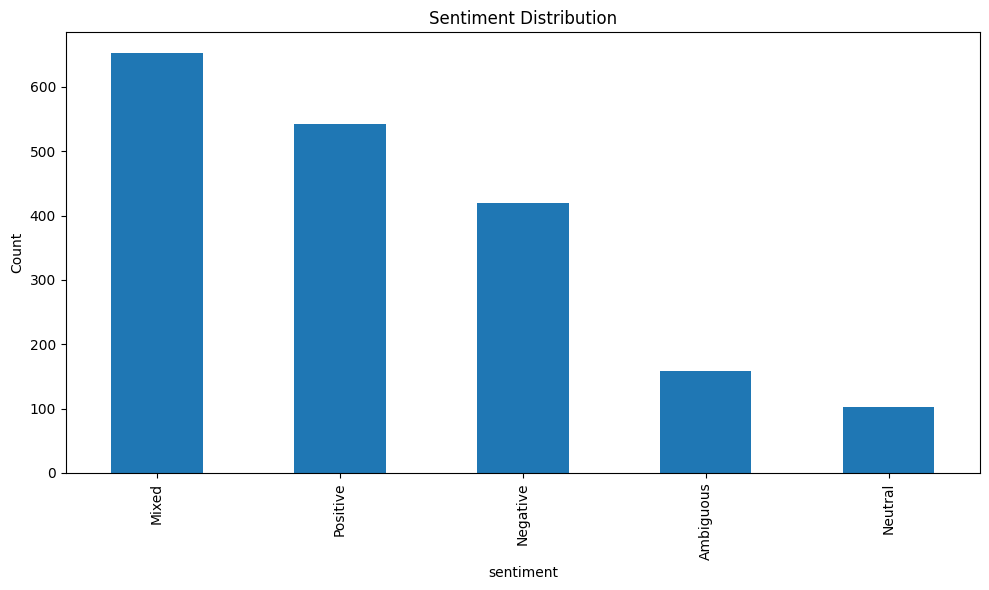

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('clean.csv')

# Display basic info
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

# Check if using text or clean_text
text_column = 'text' if 'text' in df.columns else 'clean_text'
print(f"Using column: {text_column}")

# Look at sentiment distribution
print("\nSentiment distribution:")
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)

# Visualize distribution
plt.figure(figsize=(10, 6))
sentiment_counts.plot(kind='bar')
plt.title('Sentiment Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


In [2]:
# Create label mapping
sentiment_mapping = {
    'Positive': 0,
    'Negative': 1,
    'Neutral': 2,
    'Mixed': 3,
    'Ambiguous': 4
}

# Apply mapping
df['label'] = df['sentiment'].map(sentiment_mapping)
df = df[[text_column, 'sentiment', 'label']].dropna()
df['label'] = df['label'].astype(int)

print("Label distribution:")
print(df['label'].value_counts().sort_index())

# Split data
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"\nTrain set: {len(train_df)} examples")
print(f"Test set: {len(test_df)} examples")

Label distribution:
label
0    542
1    419
2    103
3    652
4    158
Name: count, dtype: int64

Train set: 1499 examples
Test set: 375 examples


### Loading models and preparing for fine-tuning

In [6]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load pre-trained model and tokenizer
model_name = "distilbert-base-uncased-finetuned-sst-2-english" 
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=len(sentiment_mapping),
    ignore_mismatched_sizes=True 

)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased-finetuned-sst-2-english and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([5]) in the model instantiated
- classifier.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([5, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [4]:
from datasets import Dataset
from transformers import TrainingArguments, Trainer

# Convert to Hugging Face datasets
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Tokenize datasets
def tokenize_function(examples):
    return tokenizer(
        examples[text_column],
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

tokenized_train = train_dataset.map(
    tokenize_function, 
    batched=True, 
    remove_columns=[text_column, "sentiment"]
)

tokenized_test = test_dataset.map(
    tokenize_function, 
    batched=True,
    remove_columns=[text_column, "sentiment"]
)

# Define metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.argmax(-1)
    
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='weighted')
    
    return {
        "accuracy": acc, 
        "f1": f1,
    }

Map: 100%|██████████| 375/375 [00:00<00:00, 14740.44 examples/s]


In [5]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
import os
import json
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

class SimpleLoggingTrainer(Trainer):
    def __init__(self, *args, logs_dir=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.logs_dir = logs_dir
        self.step_count = 0
        
    def log(self, logs, iterator_start_time=None): 
        super().log(logs, iterator_start_time)      
        self.step_count += 1
        
        # Save logs every 10 steps
        if self.step_count % 10 == 0 and self.logs_dir:
            self.save_current_logs()
    
    def save_current_logs(self):
        try:
            log_file = os.path.join(self.logs_dir, "training_logs.json")
            with open(log_file, 'w') as f:
                json.dump(self.state.log_history, f, indent=2)
        except:
            pass

def run_cross_validation_improved(df, n_splits=5, num_epochs=5, experiment_name="sentimentmodel"):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_results = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['label'])):
        print(f"\nFOLD {fold + 1}/{n_splits}")
        print("="*30)
        
        # Create directories with experiment name
        results_dir = f"./results_{experiment_name}_fold_{fold}"
        logs_dir = f"./logs_{experiment_name}_fold_{fold}"
        os.makedirs(results_dir, exist_ok=True)
        os.makedirs(logs_dir, exist_ok=True)
        
        # Split data
        train_fold = df.iloc[train_idx].reset_index(drop=True)
        val_fold = df.iloc[val_idx].reset_index(drop=True)
        
        print(f"Train: {len(train_fold)}, Val: {len(val_fold)}")
        
        # Convert to datasets
        train_dataset = Dataset.from_pandas(train_fold)
        val_dataset = Dataset.from_pandas(val_fold)
        
        # Tokenize
        tokenized_train = train_dataset.map(tokenize_function, batched=True, 
                                          remove_columns=[text_column, "sentiment"])
        tokenized_val = val_dataset.map(tokenize_function, batched=True,
                                      remove_columns=[text_column, "sentiment"])
        
        # Load model
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=len(sentiment_mapping), ignore_mismatched_sizes=True
        )
        
        # Calculate eval steps
        batch_size = 16
        steps_per_epoch = len(train_fold) // batch_size
        eval_steps = max(50, steps_per_epoch // 3)  # 3 evaluations per epoch
        
        print(f"Steps per epoch: {steps_per_epoch}")
        print(f"Will evaluate every {eval_steps} steps")
        print(f"Early stopping patience: 3 evaluations")
        
        # IMPROVED TRAINING ARGUMENTS WITH EARLY STOPPING
        training_args = TrainingArguments(
            # Directories
            output_dir=results_dir,
            logging_dir=logs_dir,
            
            # Evaluation strategy
            evaluation_strategy="steps",
            eval_steps=eval_steps,
            
            # Saving strategy - focus on best validation loss
            save_strategy="steps",
            save_steps=eval_steps,
            save_total_limit=1,                    # Only keep the best checkpoint
            load_best_model_at_end=True,
            metric_for_best_model="eval_loss",     # Use validation loss for early stopping
            greater_is_better=False,               # Lower loss is better
            
            # Logging
            logging_steps=20,
            report_to="tensorboard",
            
            # Training hyperparameters
            learning_rate=1e-5,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size,
            num_train_epochs=num_epochs,
            weight_decay=0.01,
            warmup_steps=100,
            
            # Performance
            dataloader_pin_memory=False,
            remove_unused_columns=True,
            
            # Disable unnecessary features
            push_to_hub=False,
            hub_model_id=None,
        )
        
        # CREATE TRAINER WITH EARLY STOPPING
        trainer = SimpleLoggingTrainer(
            model=model,
            args=training_args,
            train_dataset=tokenized_train,
            eval_dataset=tokenized_val,
            compute_metrics=compute_metrics,
            logs_dir=logs_dir,
            callbacks=[
                EarlyStoppingCallback(
                    early_stopping_patience=3,     # Stop if no improvement for 3 evaluations
                    early_stopping_threshold=0.0   # Any improvement counts
                )
            ],
        )
        
        # Train with early stopping
        print("Training started with early stopping...")
        trainer.train()
        
        # Check if early stopping was triggered
        if trainer.state.epoch < num_epochs:
            print(f"Early stopping triggered at epoch {trainer.state.epoch:.2f}")
        else:
            print(f"Training completed all {num_epochs} epochs")
        
        # Final evaluation
        eval_results = trainer.evaluate()
        
        # Save final results
        cv_results.append({
            'fold': fold + 1,
            'accuracy': eval_results['eval_accuracy'],
            'f1': eval_results['eval_f1'],
            'eval_loss': eval_results['eval_loss'],
            'epochs_trained': trainer.state.epoch,
            'early_stopped': trainer.state.epoch < num_epochs
        })
        
        print(f"Final Results:")
        print(f"  Accuracy: {eval_results['eval_accuracy']:.4f}")
        print(f"  F1: {eval_results['eval_f1']:.4f}")
        print(f"  Loss: {eval_results['eval_loss']:.4f}")
        print(f"  Epochs: {trainer.state.epoch:.2f}")
        
        # Save logs one final time
        final_log_path = os.path.join(logs_dir, "final_logs.json")
        with open(final_log_path, 'w') as f:
            json.dump(trainer.state.log_history, f, indent=2)
        
        # Save training summary
        summary_path = os.path.join(logs_dir, "training_summary.json")
        with open(summary_path, 'w') as f:
            json.dump({
                'fold': fold + 1,
                'epochs_trained': trainer.state.epoch,
                'total_steps': trainer.state.global_step,
                'early_stopped': trainer.state.epoch < num_epochs,
                'final_results': cv_results[-1],
                'training_args': training_args.to_dict()
            }, f, indent=2)
        
        print(f"Logs saved to {logs_dir}")
        
        # Clear memory
        del model, trainer
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    # Save CV results
    with open(f'cv_results_{experiment_name}.json', 'w') as f:
        json.dump(cv_results, f, indent=2)
    
    # Print summary
    if cv_results:
        avg_acc = np.mean([r['accuracy'] for r in cv_results])
        std_acc = np.std([r['accuracy'] for r in cv_results])
        avg_f1 = np.mean([r['f1'] for r in cv_results])
        std_f1 = np.std([r['f1'] for r in cv_results])
        avg_epochs = np.mean([r['epochs_trained'] for r in cv_results])
        early_stopped_count = sum([r['early_stopped'] for r in cv_results])
        
        print(f"\nCROSS-VALIDATION SUMMARY")
        print("="*40)
        print(f"Accuracy: {avg_acc:.4f} ± {std_acc:.4f}")
        print(f"F1 Score: {avg_f1:.4f} ± {std_f1:.4f}")
        print(f"Average epochs: {avg_epochs:.2f}")
        print(f"Early stopped: {early_stopped_count}/{len(cv_results)} folds")
    
    return cv_results


In [ ]:
# Uncoment here to start cross validation ( takes a while )

#cv_results = run_cross_validation_improved(df, n_splits=5, num_epochs=8)


FOLD 1/5
Train: 1499, Val: 375


Map:   0%|          | 0/1499 [00:00<?, ? examples/s]

Map: 100%|██████████| 375/375 [00:00<00:00, 13890.02 examples/s]
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased-finetuned-sst-2-english and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([5]) in the model instantiated
- classifier.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([5, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Steps per epoch: 93
Will evaluate every 50 steps
Early stopping patience: 3 evaluations
Training started with early stopping...


c:\Users\Rafa Parkoureiro\anaconda3\envs\NLP\Lib\site-packages\transformers\training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


...

Map: 100%|██████████| 374/374 [00:00<00:00, 13851.27 examples/s]
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased-finetuned-sst-2-english and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([5]) in the model instantiated
- classifier.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([5, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\Rafa Parkoureiro\anaconda3\envs\NLP\Lib\site-packages\transformers\training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Steps per epoch: 93
Will evaluate every 50 steps
Early stopping patience: 3 evaluations
Training started with early stopping...


Step,Training Loss,Validation Loss,Accuracy,F1
50,1.535300,1.471182,0.347594,0.179314
100,1.202500,1.141402,0.598930,0.544929
150,0.972500,0.981607,0.649733,0.599702
200,0.793600,0.864233,0.697861,0.648377
250,0.649400,0.822179,0.713904,0.661550
300,0.638700,0.788961,0.716578,0.667852
350,0.549700,0.738748,0.721925,0.681769
400,0.445000,0.722900,0.727273,0.691954
450,0.474700,0.722483,0.735294,0.715742
500,0.338100,0.707707,0.740642,0.712989


Training completed all 8 epochs


Final Results:
  Accuracy: 0.7540
  F1: 0.7392
  Loss: 0.6891
  Epochs: 8.00
Logs saved to ./logs_sentimentmodel_fold_4

CROSS-VALIDATION SUMMARY
Accuracy: 0.7615 ± 0.0262
F1 Score: 0.7438 ± 0.0284
Average epochs: 7.67
Early stopped: 3/5 folds


In [12]:
# Load and display results
with open('cv_results_sentimentmodel.json', 'r') as f:
   cv_results = json.load(f)

for result in cv_results:
   print(f"Fold {result['fold']}: Acc={result['accuracy']:.4f}, F1={result['f1']:.4f}, Loss={result['eval_loss']:.4f}")

Fold 1: Acc=0.8080, F1=0.7950, Loss=0.5842
Fold 2: Acc=0.7467, F1=0.7276, Loss=0.6570
Fold 3: Acc=0.7307, F1=0.7106, Loss=0.7132
Fold 4: Acc=0.7680, F1=0.7465, Loss=0.6275
Fold 5: Acc=0.7540, F1=0.7392, Loss=0.6891


## Learning curves

CV Results:
Fold 1: Acc=0.8080, F1=0.7950, Loss=0.5842, Epochs=8.00, Early stopped=False
Fold 2: Acc=0.7467, F1=0.7276, Loss=0.6570, Epochs=7.45, Early stopped=True
Fold 3: Acc=0.7307, F1=0.7106, Loss=0.7132, Epochs=7.98, Early stopped=True
Fold 4: Acc=0.7680, F1=0.7465, Loss=0.6275, Epochs=6.91, Early stopped=True
Fold 5: Acc=0.7540, F1=0.7392, Loss=0.6891, Epochs=8.00, Early stopped=False

Summary:
Accuracy: 0.7615 ± 0.0262
F1 Score: 0.7438 ± 0.0284
Loaded logs for fold 1 from ./logs_sentimentmodel_fold_0/final_logs.json
Fold 1: 37 training logs, 16 eval logs
Loaded logs for fold 2 from ./logs_sentimentmodel_fold_1/final_logs.json
Fold 2: 35 training logs, 15 eval logs
Loaded logs for fold 3 from ./logs_sentimentmodel_fold_2/final_logs.json
Fold 3: 37 training logs, 16 eval logs
Loaded logs for fold 4 from ./logs_sentimentmodel_fold_3/final_logs.json
Fold 4: 32 training logs, 14 eval logs
Loaded logs for fold 5 from ./logs_sentimentmodel_fold_4/final_logs.json
Fold 5: 37 training log

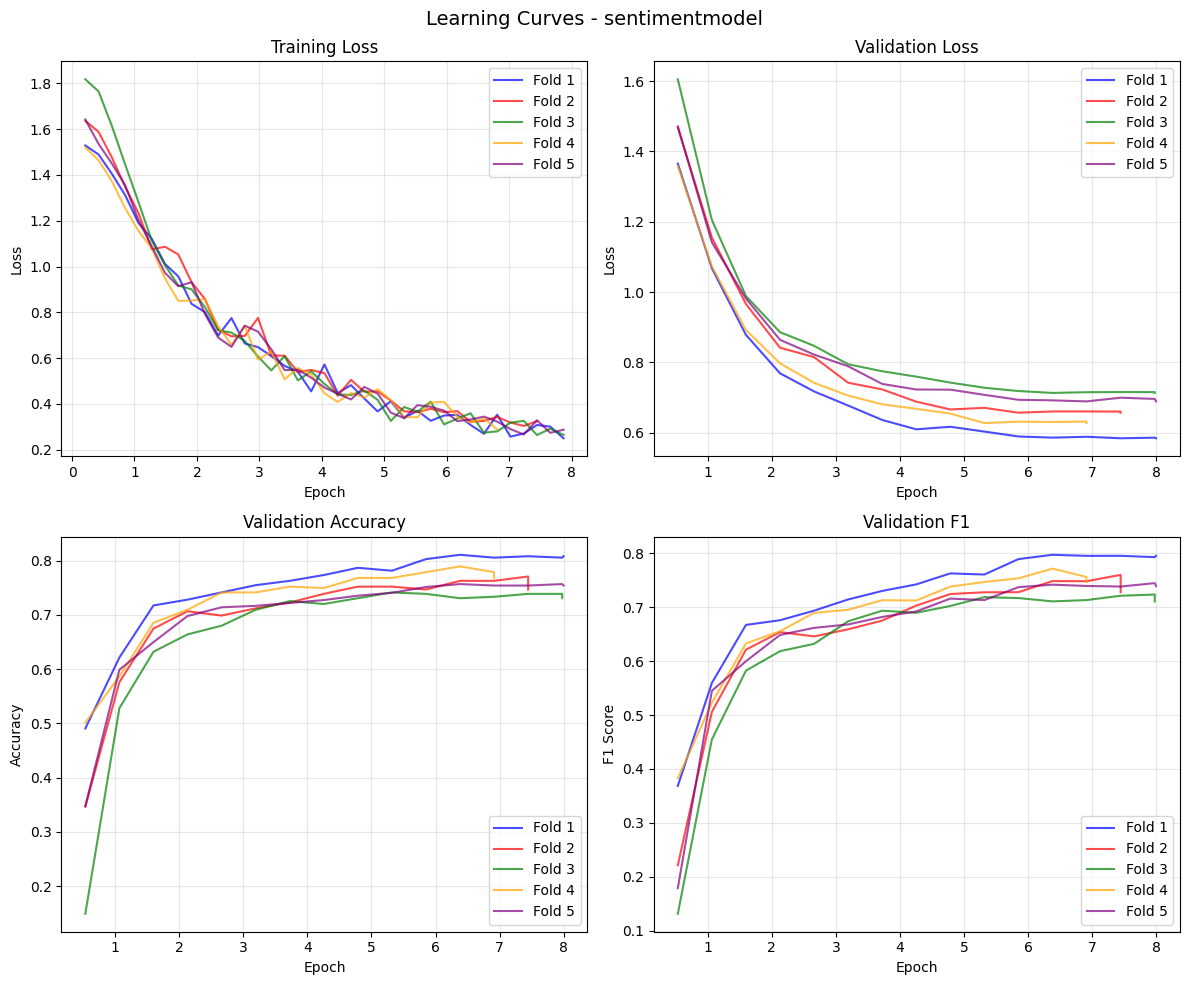

Learning curves saved as: learning_curves_sentimentmodel.png


In [7]:
import matplotlib.pyplot as plt
import json
import numpy as np

def plot_learning_curves_simple(cv_results, experiment_name="sentimentmodel"):
   """Plot learning curves from training logs"""
   
   fig, axes = plt.subplots(2, 2, figsize=(12, 10))
   fig.suptitle(f'Learning Curves - {experiment_name}', fontsize=14)
   
   colors = ['blue', 'red', 'green', 'orange', 'purple']
   
   for i, result in enumerate(cv_results):
       fold_num = result['fold']
       
       # Load logs - updated paths for your experiment
       log_paths = [
           f"./logs_{experiment_name}_fold_{fold_num-1}/final_logs.json",
           f"./logs_{experiment_name}_fold_{fold_num-1}/training_logs.json"
       ]
       
       logs = None
       for log_path in log_paths:
           try:
               with open(log_path, 'r') as f:
                   logs = json.load(f)
               print(f"Loaded logs for fold {fold_num} from {log_path}")
               break
           except:
               continue
       
       if logs is None:
           print(f"Could not find logs for fold {fold_num}")
           continue
       
       # Separate train and eval logs
       train_logs = [log for log in logs if 'loss' in log and 'eval_loss' not in log]
       eval_logs = [log for log in logs if 'eval_loss' in log]
       
       print(f"Fold {fold_num}: {len(train_logs)} training logs, {len(eval_logs)} eval logs")
       
       if train_logs and eval_logs:
           color = colors[i % len(colors)]
           
           # Training loss
           train_epochs = [log['epoch'] for log in train_logs]
           train_losses = [log['loss'] for log in train_logs]
           axes[0, 0].plot(train_epochs, train_losses, color=color, alpha=0.7, label=f'Fold {fold_num}')
           
           # Validation loss
           eval_epochs = [log['epoch'] for log in eval_logs]
           eval_losses = [log['eval_loss'] for log in eval_logs]
           axes[0, 1].plot(eval_epochs, eval_losses, color=color, alpha=0.7, label=f'Fold {fold_num}')
           
           # Validation accuracy
           eval_accs = [log.get('eval_accuracy', 0) for log in eval_logs]
           axes[1, 0].plot(eval_epochs, eval_accs, color=color, alpha=0.7, label=f'Fold {fold_num}')
           
           # Validation F1
           eval_f1s = [log.get('eval_f1', 0) for log in eval_logs]
           axes[1, 1].plot(eval_epochs, eval_f1s, color=color, alpha=0.7, label=f'Fold {fold_num}')
       else:
           print(f"No training or eval logs found for fold {fold_num}")
   
   # Configure plots
   axes[0, 0].set_title('Training Loss')
   axes[0, 0].set_xlabel('Epoch')
   axes[0, 0].set_ylabel('Loss')
   axes[0, 0].legend()
   axes[0, 0].grid(True, alpha=0.3)
   
   axes[0, 1].set_title('Validation Loss')
   axes[0, 1].set_xlabel('Epoch')
   axes[0, 1].set_ylabel('Loss')
   axes[0, 1].legend()
   axes[0, 1].grid(True, alpha=0.3)
   
   axes[1, 0].set_title('Validation Accuracy')
   axes[1, 0].set_xlabel('Epoch')
   axes[1, 0].set_ylabel('Accuracy')
   axes[1, 0].legend()
   axes[1, 0].grid(True, alpha=0.3)
   
   axes[1, 1].set_title('Validation F1')
   axes[1, 1].set_xlabel('Epoch')
   axes[1, 1].set_ylabel('F1 Score')
   axes[1, 1].legend()
   axes[1, 1].grid(True, alpha=0.3)
   
   plt.tight_layout()
   plt.savefig(f'learning_curves_{experiment_name}.png', dpi=300, bbox_inches='tight')
   plt.show()
   
   print(f"Learning curves saved as: learning_curves_{experiment_name}.png")

# Load CV results and plot
try:
   with open('cv_results_sentimentmodel.json', 'r') as f:
       cv_results = json.load(f)
   
   print("CV Results:")
   for result in cv_results:
       early_stopped = result.get('early_stopped', False)
       epochs = result.get('epochs_trained', 'unknown')
       print(f"Fold {result['fold']}: Acc={result['accuracy']:.4f}, F1={result['f1']:.4f}, "
             f"Loss={result['eval_loss']:.4f}, Epochs={epochs:.2f}, Early stopped={early_stopped}")
   
   # Calculate summary
   accuracies = [r['accuracy'] for r in cv_results]
   f1_scores = [r['f1'] for r in cv_results]
   
   print(f"\nSummary:")
   print(f"Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
   print(f"F1 Score: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
   
   # Plot the curves
   plot_learning_curves_simple(cv_results, experiment_name="sentimentmodel")
   
except FileNotFoundError:
   print("cv_results_sentimentmodel.json not found. Make sure training completed successfully.")
except Exception as e:
   print(f"Error: {e}")

# Confusion matrix

Creating confusion matrix analysis...
Loading best model from Fold 1
F1 Score: 0.7950
Found checkpoints: ['checkpoint-700']
Using latest checkpoint: ./results_sentimentmodel_fold_0\checkpoint-700
Model loaded successfully from: ./results_sentimentmodel_fold_0\checkpoint-700
Using validation set from fold 1 as test set (375 samples)
Getting predictions for 375 samples...


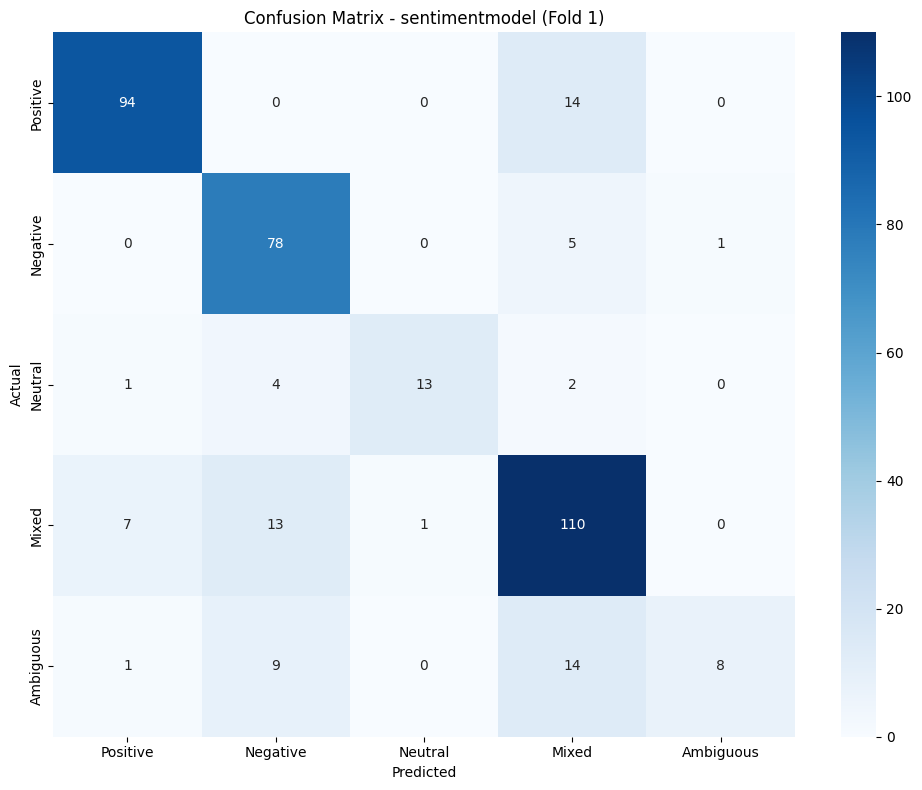


Classification Report:
              precision    recall  f1-score   support

    Positive     0.9126    0.8704    0.8910       108
    Negative     0.7500    0.9286    0.8298        84
     Neutral     0.9286    0.6500    0.7647        20
       Mixed     0.7586    0.8397    0.7971       131
   Ambiguous     0.8889    0.2500    0.3902        32

    accuracy                         0.8080       375
   macro avg     0.8477    0.7077    0.7346       375
weighted avg     0.8212    0.8080    0.7950       375


Per-Class Analysis:
Positive    : 0.8704 (108 samples)
Negative    : 0.9286 ( 84 samples)
Neutral     : 0.6500 ( 20 samples)
Mixed       : 0.8397 (131 samples)
Ambiguous   : 0.2500 ( 32 samples)

Most Confused Pairs:
Positive     -> Mixed       :  14 times
Ambiguous    -> Mixed       :  14 times
Mixed        -> Negative    :  13 times
Ambiguous    -> Negative    :   9 times
Mixed        -> Positive    :   7 times
Negative     -> Mixed       :   5 times
Neutral      -> Negative    :

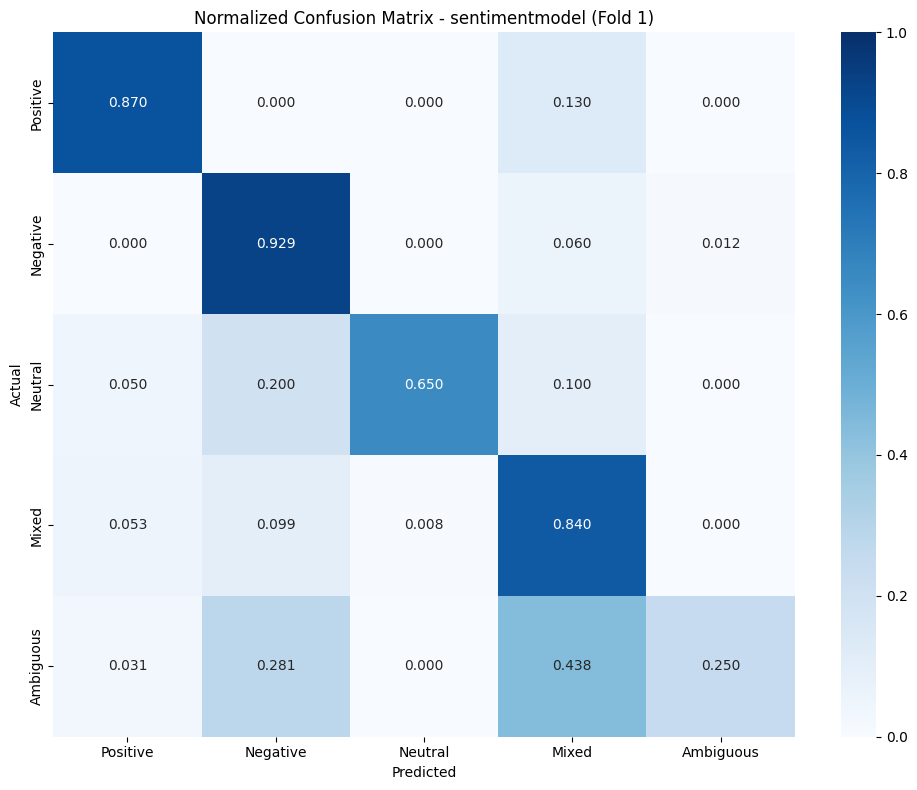


Confusion matrices saved as:
- confusion_matrix_sentimentmodel.png (raw counts)
- confusion_matrix_normalized_sentimentmodel.png (percentages)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import json

def load_best_model(cv_results, experiment_name="sentimentmodel"):
   """Load the best performing model from CV results"""
   
   # Find best fold based on F1 score
   best_fold = max(cv_results, key=lambda x: x['f1'])
   best_fold_num = best_fold['fold']
   
   print(f"Loading best model from Fold {best_fold_num}")
   print(f"F1 Score: {best_fold['f1']:.4f}")
   
   # Check what directories actually exist
   import os
   import glob
   
   # Look for the results directory for the best fold - updated path
   results_dir = f"./results_{experiment_name}_fold_{best_fold_num-1}"
   
   if not os.path.exists(results_dir):
       print(f"Results directory doesn't exist: {results_dir}")
       return None, None, None
   
   # Find checkpoint directories inside
   checkpoint_dirs = glob.glob(os.path.join(results_dir, "checkpoint-*"))
   
   if not checkpoint_dirs:
       print(f"No checkpoint directories found in {results_dir}")
       return None, None, None
   
   # Use the latest checkpoint (highest number)
   checkpoint_dirs.sort(key=lambda x: int(x.split('-')[-1]))
   latest_checkpoint = checkpoint_dirs[-1]
   
   print(f"Found checkpoints: {[os.path.basename(d) for d in checkpoint_dirs]}")
   print(f"Using latest checkpoint: {latest_checkpoint}")
   
   try:
       model = AutoModelForSequenceClassification.from_pretrained(latest_checkpoint)
       tokenizer = AutoTokenizer.from_pretrained(model_name)
       print(f"Model loaded successfully from: {latest_checkpoint}")
       return model, tokenizer, best_fold_num
   except Exception as e:
       print(f"Failed to load model: {e}")
       return None, None, None

def get_predictions(model, tokenizer, texts, labels, batch_size=16):
   """Get model predictions for a dataset"""
   
   device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
   model.to(device)
   model.eval()
   
   predictions = []
   
   print(f"Getting predictions for {len(texts)} samples...")
   
   # Process in batches
   for i in range(0, len(texts), batch_size):
       batch_texts = texts[i:i+batch_size]
       
       # Tokenize batch
       inputs = tokenizer(
           batch_texts,
           truncation=True,
           padding=True,
           max_length=512,
           return_tensors='pt'
       )
       inputs = {k: v.to(device) for k, v in inputs.items()}
       
       # Get predictions
       with torch.no_grad():
           outputs = model(**inputs)
           batch_preds = torch.argmax(outputs.logits, dim=-1)
           predictions.extend(batch_preds.cpu().numpy())
   
   return np.array(predictions)

def create_confusion_matrix(cv_results, df, experiment_name="sentimentmodel"):
   """Create confusion matrix using the best model on test data"""
   
   # Load best model
   model, tokenizer, best_fold_num = load_best_model(cv_results, experiment_name)
   if model is None:
       return
   
   # Recreate the same CV split to get the test set for the best fold
   skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
   
   for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['label'])):
       if fold + 1 == best_fold_num:
           # This is our best fold - use its validation set as test set
           test_texts = df.iloc[val_idx][text_column].tolist()
           test_labels = df.iloc[val_idx]['label'].tolist()
           break
   
   print(f"Using validation set from fold {best_fold_num} as test set ({len(test_texts)} samples)")
   
   # Get predictions
   predictions = get_predictions(model, tokenizer, test_texts, test_labels)
   
   # Create confusion matrix
   cm = confusion_matrix(test_labels, predictions)
   
   # Get class names
   label_names = list(sentiment_mapping.keys())
   
   # Plot confusion matrix
   plt.figure(figsize=(10, 8))
   sns.heatmap(cm, 
               annot=True, 
               fmt='d', 
               cmap='Blues',
               xticklabels=label_names,
               yticklabels=label_names)
   plt.title(f'Confusion Matrix - {experiment_name} (Fold {best_fold_num})')
   plt.xlabel('Predicted')
   plt.ylabel('Actual')
   plt.tight_layout()
   plt.savefig(f'confusion_matrix_{experiment_name}.png', dpi=300, bbox_inches='tight')
   plt.show()
   
   # Print classification report
   print("\nClassification Report:")
   print("="*50)
   report = classification_report(test_labels, predictions, 
                                target_names=label_names, 
                                digits=4)
   print(report)
   
   # Calculate per-class accuracy
   print("\nPer-Class Analysis:")
   print("="*50)
   for i, label in enumerate(label_names):
       class_mask = np.array(test_labels) == i
       if class_mask.sum() > 0:
           class_accuracy = (np.array(predictions)[class_mask] == i).mean()
           class_total = class_mask.sum()
           print(f"{label:12}: {class_accuracy:.4f} ({class_total:3d} samples)")
   
   # Most confused pairs
   print("\nMost Confused Pairs:")
   print("="*50)
   confusion_pairs = []
   for i in range(len(label_names)):
       for j in range(len(label_names)):
           if i != j and cm[i, j] > 0:
               confusion_pairs.append((label_names[i], label_names[j], cm[i, j]))
   
   # Sort by confusion count
   confusion_pairs.sort(key=lambda x: x[2], reverse=True)
   
   for actual, predicted, count in confusion_pairs[:10]:  # Top 10
       print(f"{actual:12} -> {predicted:12}: {count:3d} times")
   
   return cm, predictions, test_labels

def create_normalized_confusion_matrix(cv_results, df, experiment_name="sentimentmodel"):
   """Create normalized confusion matrix (percentages)"""
   
   model, tokenizer, best_fold_num = load_best_model(cv_results, experiment_name)
   if model is None:
       return
   
   # Get test data for best fold
   skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
   
   for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['label'])):
       if fold + 1 == best_fold_num:
           test_texts = df.iloc[val_idx][text_column].tolist()
           test_labels = df.iloc[val_idx]['label'].tolist()
           break
   
   # Get predictions
   predictions = get_predictions(model, tokenizer, test_texts, test_labels)
   
   # Create normalized confusion matrix
   cm = confusion_matrix(test_labels, predictions)
   cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
   
   # Get class names
   label_names = list(sentiment_mapping.keys())
   
   # Plot normalized confusion matrix
   plt.figure(figsize=(10, 8))
   sns.heatmap(cm_normalized, 
               annot=True, 
               fmt='.3f', 
               cmap='Blues',
               xticklabels=label_names,
               yticklabels=label_names,
               vmin=0, 
               vmax=1)
   plt.title(f'Normalized Confusion Matrix - {experiment_name} (Fold {best_fold_num})')
   plt.xlabel('Predicted')
   plt.ylabel('Actual')
   plt.tight_layout()
   plt.savefig(f'confusion_matrix_normalized_{experiment_name}.png', dpi=300, bbox_inches='tight')
   plt.show()
   
   return cm_normalized

# Load CV results and create confusion matrices
try:
   with open('cv_results_sentimentmodel.json', 'r') as f:
       cv_results = json.load(f)
   
   print("Creating confusion matrix analysis...")
   print("="*50)
   
   # Create regular confusion matrix
   cm, predictions, test_labels = create_confusion_matrix(cv_results, df, experiment_name="sentimentmodel")
   
   print("\n" + "="*50)
   
   # Create normalized confusion matrix
   cm_normalized = create_normalized_confusion_matrix(cv_results, df, experiment_name="sentimentmodel")
   
   print("\nConfusion matrices saved as:")
   print("- confusion_matrix_sentimentmodel.png (raw counts)")
   print("- confusion_matrix_normalized_sentimentmodel.png (percentages)")
   
except FileNotFoundError:
   print("cv_results_sentimentmodel.json not found")
except Exception as e:
   print(f"Error: {e}")


# Where does the model fail?

In [15]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import json

def analyze_model_failures(cv_results, df, experiment_name="sentimentmodel", num_examples=5):
   """Analyze where the model fails and show actual text examples"""
   
   # Load best model (reuse the function from confusion matrix code)
   model, tokenizer, best_fold_num = load_best_model(cv_results, experiment_name)
   if model is None:
       return
   
   # Get test data for best fold
   skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
   
   for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['label'])):
       if fold + 1 == best_fold_num:
           test_df = df.iloc[val_idx].reset_index(drop=True)
           break
   
   # Get predictions
   test_texts = test_df[text_column].tolist()
   test_labels = test_df['label'].tolist()
   predictions = get_predictions(model, tokenizer, test_texts, test_labels)
   
   # Find misclassified examples
   misclassified_mask = predictions != np.array(test_labels)
   misclassified_indices = np.where(misclassified_mask)[0]
   
   print(f"FAILURE ANALYSIS - {experiment_name} Model from Fold {best_fold_num}")
   print("="*60)
   print(f"Total test samples: {len(test_texts)}")
   print(f"Misclassified: {len(misclassified_indices)} ({len(misclassified_indices)/len(test_texts)*100:.1f}%)")
   
   # Get emotion names
   label_names = list(sentiment_mapping.keys())
   reverse_mapping = {v: k for k, v in sentiment_mapping.items()}
   
   # Analyze failures by emotion
   print(f"\nFAILURE BREAKDOWN BY EMOTION:")
   print("-" * 40)
   
   for emotion_id, emotion_name in reverse_mapping.items():
       # Get all samples of this emotion
       emotion_mask = np.array(test_labels) == emotion_id
       emotion_indices = np.where(emotion_mask)[0]
       
       if len(emotion_indices) == 0:
           continue
           
       # Get misclassified samples of this emotion
       emotion_failures = np.intersect1d(emotion_indices, misclassified_indices)
       
       if len(emotion_failures) > 0:
           accuracy = 1 - (len(emotion_failures) / len(emotion_indices))
           print(f"\n{emotion_name.upper()} (Accuracy: {accuracy:.3f})")
           print(f"Failed: {len(emotion_failures)}/{len(emotion_indices)} samples")
           
           # Show examples of failures
           print(f"\nWorst {min(num_examples, len(emotion_failures))} examples:")
           
           for i, idx in enumerate(emotion_failures[:num_examples]):
               actual = reverse_mapping[test_labels[idx]]
               predicted = reverse_mapping[predictions[idx]]
               text = test_texts[idx]
               
               print(f"\n{i+1}. Text: \"{text}\"")
               print(f"   Actual: {actual} → Predicted: {predicted}")
   
   # Most confusing pairs with examples
   print(f"\n\nMOST CONFUSING EMOTION PAIRS:")
   print("="*60)
   
   confusion_pairs = {}
   for idx in misclassified_indices:
       actual = test_labels[idx]
       predicted = predictions[idx]
       pair = (actual, predicted)
       
       if pair not in confusion_pairs:
           confusion_pairs[pair] = []
       confusion_pairs[pair].append(idx)
   
   # Sort by frequency
   sorted_pairs = sorted(confusion_pairs.items(), key=lambda x: len(x[1]), reverse=True)
   
   for i, ((actual_id, predicted_id), indices) in enumerate(sorted_pairs[:3]):
       actual_name = reverse_mapping[actual_id]
       predicted_name = reverse_mapping[predicted_id]
       
       print(f"\n{i+1}. {actual_name} → {predicted_name} ({len(indices)} times)")
       print("-" * 30)
       
       for j, idx in enumerate(indices[:3]):  # Show 3 examples
           text = test_texts[idx]
           print(f"   Example {j+1}: \"{text}\"")

# Run the analysis
try:
   with open('cv_results_sentimentmodel.json', 'r') as f:
       cv_results = json.load(f)
   
   analyze_model_failures(cv_results, df, experiment_name="sentimentmodel", num_examples=5)
   
except FileNotFoundError:
   print("cv_results_sentimentmodel.json not found")
except Exception as e:
   print(f"Error: {e}")

Loading best model from Fold 1
F1 Score: 0.7950
Found checkpoints: ['checkpoint-700']
Using latest checkpoint: ./results_sentimentmodel_fold_0\checkpoint-700
Model loaded successfully from: ./results_sentimentmodel_fold_0\checkpoint-700
Getting predictions for 375 samples...
FAILURE ANALYSIS - sentimentmodel Model from Fold 1
Total test samples: 375
Misclassified: 72 (19.2%)

FAILURE BREAKDOWN BY EMOTION:
----------------------------------------

POSITIVE (Accuracy: 0.870)
Failed: 14/108 samples

Worst 5 examples:

1. Text: "The standing ovation after my play's premiere was an overwhelming blend of pride, gratitude, and sheer disbelief that my work touched so many."
   Actual: Positive → Predicted: Mixed

2. Text: "The look of joy on my sibling’s face when I handed them the gift I had made left me overwhelmed by a sense of love, but it was tinged with a small fear that it wouldn’t live up to their expectations."
   Actual: Positive → Predicted: Mixed

3. Text: "As I unpacked the small 

## We can understand that even some results are subjective for us humans

Creating error analysis to understand WHY misclassifications happen...
Loading best model from Fold 1
F1 Score: 0.7950
Found checkpoints: ['checkpoint-700']
Using latest checkpoint: ./results_sentimentmodel_fold_0\checkpoint-700
Model loaded successfully from: ./results_sentimentmodel_fold_0\checkpoint-700
Loaded best sentimentmodel model from Fold 1
Getting predictions for 375 samples...


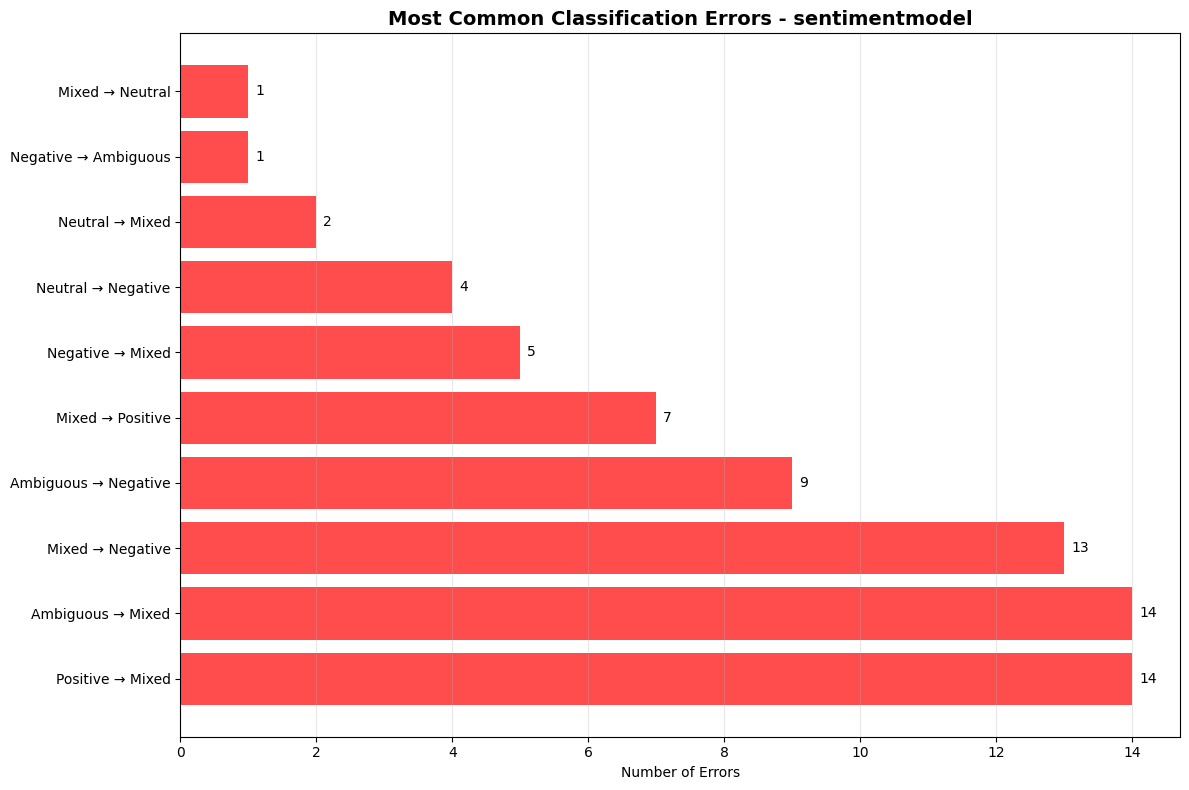


Error Analysis Summary:
Positive → Mixed: 14 errors (20.0%)
Ambiguous → Mixed: 14 errors (20.0%)
Mixed → Negative: 13 errors (18.6%)
Ambiguous → Negative: 9 errors (12.9%)
Mixed → Positive: 7 errors (10.0%)


{('Positive', 'Mixed'): 14,
 ('Mixed', 'Positive'): 7,
 ('Mixed', 'Negative'): 13,
 ('Ambiguous', 'Mixed'): 14,
 ('Negative', 'Ambiguous'): 1,
 ('Ambiguous', 'Negative'): 9,
 ('Negative', 'Mixed'): 5,
 ('Neutral', 'Mixed'): 2,
 ('Mixed', 'Neutral'): 1,
 ('Neutral', 'Negative'): 4,
 ('Ambiguous', 'Positive'): 1,
 ('Neutral', 'Positive'): 1}

In [ ]:
def load_trained_model(experiment_name="sentimentmodel"):
   """Load your best trained model"""
   try:
       with open(f'cv_results_{experiment_name}.json', 'r') as f:
           cv_results = json.load(f)
       
       model, tokenizer, fold_num = load_best_model(cv_results, experiment_name)
       if model is None:
           print("Could not load trained model")
           return None, None, None
       
       device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
       model.to(device)
       model.eval()
       
       print(f"Loaded best {experiment_name} model from Fold {fold_num}")
       return model, tokenizer, device
       
   except Exception as e:
       print(f"Error loading model: {e}")
       return None, None, None
def create_error_analysis_visualization(cv_results, df, experiment_name="sentimentmodel"):
   """Analyze WHY the model makes specific classification errors"""
   
   print("Creating error analysis to understand WHY misclassifications happen...")
   
   try:
       # Load model
       model, tokenizer, device = load_trained_model(experiment_name)
       if model is None:
           return
       
       # Get test data and predictions
       skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
       best_fold = max(cv_results, key=lambda x: x['f1'])['fold']
       
       for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['label'])):
           if fold + 1 == best_fold:
               test_df = df.iloc[val_idx].reset_index(drop=True)
               break
       
       test_texts = test_df[text_column].tolist()
       test_labels = test_df['label'].tolist()
       predictions = get_predictions(model, tokenizer, test_texts, test_labels)
       
       # Find misclassified examples
       misclassified_mask = predictions != np.array(test_labels)
       misclassified_indices = np.where(misclassified_mask)[0]
       
       reverse_mapping = {v: k for k, v in sentiment_mapping.items()}
       
       # Count error types
       error_counts = {}
       for idx in misclassified_indices:
           true_label = test_labels[idx]
           pred_label = predictions[idx]
           pair = (reverse_mapping[true_label], reverse_mapping[pred_label])
           
           if pair not in error_counts:
               error_counts[pair] = 0
           error_counts[pair] += 1
       
       # Sort by frequency
       sorted_errors = sorted(error_counts.items(), key=lambda x: x[1], reverse=True)
       
       # Create visualization
       plt.figure(figsize=(12, 8))
       
       error_pairs = [f"{pair[0]} → {pair[1]}" for pair, _ in sorted_errors[:10]]
       counts = [count for _, count in sorted_errors[:10]]
       
       bars = plt.barh(error_pairs, counts, alpha=0.7, color='red')
       plt.title(f'Most Common Classification Errors - {experiment_name}', fontsize=14, fontweight='bold')
       plt.xlabel('Number of Errors')
       plt.grid(axis='x', alpha=0.3)
       
       # Add count labels
       for i, (bar, count) in enumerate(zip(bars, counts)):
           plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                   str(count), va='center', fontsize=10)
       
       plt.tight_layout()
       plt.savefig(f'error_analysis_{experiment_name}.png', dpi=300, bbox_inches='tight')
       plt.show()
       
       # Print summary
       print(f"\nError Analysis Summary:")
       print("=" * 30)
       total_errors = sum(counts)
       for (true_emotion, pred_emotion), count in sorted_errors[:5]:
           percentage = (count / total_errors) * 100
           print(f"{true_emotion} → {pred_emotion}: {count} errors ({percentage:.1f}%)")
       
       return error_counts
       
   except Exception as e:
       print(f"Error: {e}")

create_error_analysis_visualization(cv_results, df, experiment_name="sentimentmodel")

### Let's test with user input text

In [ ]:
import torch
import numpy as np
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import json



def predict_emotion(text, model, tokenizer, device):
   """Predict emotion for a single text"""
   
   # Tokenize input
   inputs = tokenizer(
       text,
       truncation=True,
       padding=True,
       max_length=512,
       return_tensors='pt'
   )
   inputs = {k: v.to(device) for k, v in inputs.items()}
   
   # Get prediction
   with torch.no_grad():
       outputs = model(**inputs)
       probabilities = torch.softmax(outputs.logits, dim=-1)
       predicted_class = torch.argmax(probabilities, dim=-1).item()
       confidence = probabilities[0][predicted_class].item()
       
       # Get all probabilities for detailed analysis
       all_probs = probabilities[0].cpu().numpy()
   
   return predicted_class, confidence, all_probs

def predict_single_text(input_text, experiment_name="sentimentmodel"):
   """Simple function to predict emotion for one text"""
   
   print(f"EMOTION PREDICTION - {experiment_name}")
   print("="*40)
   print(f"Input: \"{input_text}\"")
   print()
   
   # Load model
   model, tokenizer, device = load_trained_model(experiment_name)
   if model is None:
       return
   
   # Get emotion mapping
   reverse_mapping = {v: k for k, v in sentiment_mapping.items()}
   emotion_names = list(sentiment_mapping.keys())
   
   # Predict
   predicted_class, confidence, all_probs = predict_emotion(input_text, model, tokenizer, device)
   predicted_emotion = reverse_mapping[predicted_class]
   
   # Display results
   print(f"PREDICTION RESULTS:")
   print("-" * 30)
   print(f"Predicted Emotion: {predicted_emotion}")
   print(f"Confidence: {confidence:.3f}")
   print()
   
   print("All Emotion Probabilities:")
   print("-" * 30)
   for i, (emotion, prob) in enumerate(zip(emotion_names, all_probs)):
       bar = "█" * int(prob * 20)  # Visual bar
       print(f"{emotion:12}: {prob:.3f} {bar}")
   
   return predicted_emotion, confidence, all_probs


def analyze_confidence_distribution(texts, experiment_name="sentimentmodel"):
   """Analyze confidence distribution across predictions"""
   
   print(f"CONFIDENCE ANALYSIS - {experiment_name}")
   print("="*30)
   
   # Load model
   model, tokenizer, device = load_trained_model(experiment_name)
   if model is None:
       return
   
   confidences = []
   emotions = []
   
   for text in texts:
       predicted_class, confidence, _ = predict_emotion(text, model, tokenizer, device)
       confidences.append(confidence)
       emotions.append(predicted_class)
   
   # Statistics
   avg_confidence = np.mean(confidences)
   std_confidence = np.std(confidences)
   min_confidence = np.min(confidences)
   max_confidence = np.max(confidences)
   
   print(f"Average confidence: {avg_confidence:.3f}")
   print(f"Std deviation: {std_confidence:.3f}")
   print(f"Min confidence: {min_confidence:.3f}")
   print(f"Max confidence: {max_confidence:.3f}")
   
   # Low confidence predictions
   low_confidence_threshold = 0.5
   low_confidence_indices = [i for i, conf in enumerate(confidences) if conf < low_confidence_threshold]
   
   if low_confidence_indices:
       print(f"\nLow confidence predictions (< {low_confidence_threshold}):")
       for idx in low_confidence_indices[:5]:  # Show first 5
           print(f"  {confidences[idx]:.3f}: \"{texts[idx][:60]}...\"")

# Text to be predicted:
predict_single_text("I'm feeling so good for being sad", experiment_name="sentimentmodel")


EMOTION PREDICTION - sentimentmodel
Input: "I'm feeling so good for being sad"

Loading best model from Fold 1
F1 Score: 0.7950
Found checkpoints: ['checkpoint-700']
Using latest checkpoint: ./results_sentimentmodel_fold_0\checkpoint-700
Model loaded successfully from: ./results_sentimentmodel_fold_0\checkpoint-700
Loaded best sentimentmodel model from Fold 1
PREDICTION RESULTS:
------------------------------
Predicted Emotion: Positive
Confidence: 0.973

All Emotion Probabilities:
------------------------------
Positive    : 0.973 ███████████████████
Negative    : 0.009 
Neutral     : 0.007 
Mixed       : 0.005 
Ambiguous   : 0.007 


('Positive',
 0.9732484221458435,
 array([0.9732484 , 0.00873345, 0.00665509, 0.0047564 , 0.00660679],
       dtype=float32))

# Interesting visualizations

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import torch
import json
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from math import pi

# Set professional style
plt.style.use('default')
sns.set_palette("husl")

def create_cross_validation_performance_plot(experiment_name="sentimentmodel"):
    """Visualize cross-validation performance across folds"""
    
    print("Creating CV performance visualization...")
    
    try:
        with open(f'cv_results_{experiment_name}.json', 'r') as f:
            cv_results = json.load(f)
        
        # Extract metrics
        folds = [r['fold'] for r in cv_results]
        accuracies = [r['accuracy'] for r in cv_results]
        f1_scores = [r['f1'] for r in cv_results]
        losses = [r['eval_loss'] for r in cv_results]
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle(f'Cross-Validation Performance Analysis - {experiment_name}', fontsize=16, fontweight='bold')
        
        # 1. Performance by fold
        x = np.arange(len(folds))
        width = 0.35
        
        bars1 = axes[0, 0].bar(x - width/2, accuracies, width, label='Accuracy', alpha=0.8)
        bars2 = axes[0, 0].bar(x + width/2, f1_scores, width, label='F1 Score', alpha=0.8)
        
        axes[0, 0].set_title('Performance Metrics by Fold')
        axes[0, 0].set_xlabel('Fold')
        axes[0, 0].set_ylabel('Score')
        axes[0, 0].set_xticks(x)
        axes[0, 0].set_xticklabels([f'Fold {f}' for f in folds])
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                               f'{height:.3f}', ha='center', va='bottom', fontsize=9)
        
        # 2. Loss by fold
        bars = axes[0, 1].bar(folds, losses, color='red', alpha=0.7)
        axes[0, 1].set_title('Validation Loss by Fold')
        axes[0, 1].set_xlabel('Fold')
        axes[0, 1].set_ylabel('Loss')
        axes[0, 1].grid(True, alpha=0.3)
        
        for bar, loss in zip(bars, losses):
            axes[0, 1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                           f'{loss:.3f}', ha='center', va='bottom', fontsize=9)
        
        # 3. Performance consistency
        metrics = ['Accuracy', 'F1 Score', 'Loss']
        means = [np.mean(accuracies), np.mean(f1_scores), np.mean(losses)]
        stds = [np.std(accuracies), np.std(f1_scores), np.std(losses)]
        
        bars = axes[1, 0].bar(metrics, means, yerr=stds, capsize=5, alpha=0.7)
        axes[1, 0].set_title('Average Performance ± Standard Deviation')
        axes[1, 0].set_ylabel('Score')
        axes[1, 0].grid(True, alpha=0.3)
        
        for bar, mean, std in zip(bars, means, stds):
            axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + std + 0.01,
                           f'{mean:.3f}±{std:.3f}', ha='center', va='bottom', fontsize=9)
        
        # 4. Performance stability radar
        categories = [f'Fold {f}' for f in folds]
        values_acc = accuracies + [accuracies[0]]  # Complete the circle
        values_f1 = f1_scores + [f1_scores[0]]
        
        angles = [n / float(len(folds)) * 2 * pi for n in range(len(folds))]
        angles += angles[:1]
        
        ax_radar = plt.subplot(2, 2, 4, projection='polar')
        ax_radar.plot(angles, values_acc, 'o-', linewidth=2, label='Accuracy')
        ax_radar.fill(angles, values_acc, alpha=0.25)
        ax_radar.plot(angles, values_f1, 'o-', linewidth=2, label='F1 Score')
        ax_radar.fill(angles, values_f1, alpha=0.25)
        
        ax_radar.set_xticks(angles[:-1])
        ax_radar.set_xticklabels(categories)
        ax_radar.set_ylim(0, 1)
        ax_radar.set_title('Performance Consistency Across Folds', pad=20)
        ax_radar.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
        
        plt.tight_layout()
        plt.savefig(f'cv_performance_analysis_{experiment_name}.png', dpi=300, bbox_inches='tight')
        plt.show()
        
    except Exception as e:
        print(f"Error: {e}")

def create_model_interpretability_plot(experiment_name="sentimentmodel"):
    """Create interpretability visualization using real misclassified examples"""
    
    print("Creating model interpretability using real misclassified examples...")
    
    # Use the actual misclassified examples from failure analysis
    misclassified_examples = [
        {
            'text': "The standing ovation after my play's premiere was an overwhelming blend of pride, gratitude, and sheer disbelief that my work touched so many.",
            'true': 'Positive',
            'predicted': 'Mixed'
        },
        {
            'text': "When my colleague took credit for my idea during the meeting, I felt a searing anger at their dishonesty but kept it tempered with a quiet resolve to address the situation professionally later.",
            'true': 'Negative',
            'predicted': 'Ambiguous'
        },
        {
            'text': "I've been feeling a little numb lately, like I'm disconnected from everything around me. 🤷‍♂️",
            'true': 'Neutral',
            'predicted': 'Negative'
        },
        {
            'text': "Apologizing to my team for an error I made was difficult, but their understanding and support left me feeling both humbled and appreciated.",
            'true': 'Mixed',
            'predicted': 'Positive'
        },
        {
            'text': "I stared at the blank canvas, frustration building with every moment of doubt, but somewhere within, a flicker of inspiration reminded me why I began creating in the first place.",
            'true': 'Ambiguous',
            'predicted': 'Mixed'
        }
    ]
    
    try:
        model, tokenizer, device = load_trained_model(experiment_name)
        if model is None:
            return
        
        fig, axes = plt.subplots(len(misclassified_examples), 1, figsize=(16, 3*len(misclassified_examples)))
        if len(misclassified_examples) == 1:
            axes = [axes]
            
        fig.suptitle(f'Model Interpretability - Real Misclassified Examples ({experiment_name})', 
                    fontsize=16, fontweight='bold')
        
        for i, example in enumerate(misclassified_examples):
            text = example['text']
            true_emotion = example['true']
            expected_pred = example['predicted']
            
            # Get actual model prediction
            predicted_class, confidence, all_probs = predict_emotion(text, model, tokenizer, device)
            reverse_mapping = {v: k for k, v in sentiment_mapping.items()}
            actual_pred = reverse_mapping[predicted_class]
            
            # Create probability visualization
            emotion_names = list(sentiment_mapping.keys())
            
            # Color coding: green for true, red for predicted, blue for others
            colors = []
            for name in emotion_names:
                if name == true_emotion:
                    colors.append('green')
                elif name == actual_pred:
                    colors.append('red')
                else:
                    colors.append('lightblue')
            
            # Create horizontal bar chart
            bars = axes[i].barh(emotion_names, all_probs, color=colors, alpha=0.7)
            
            # Add probability values
            for j, (bar, prob) in enumerate(zip(bars, all_probs)):
                axes[i].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                           f'{prob:.3f}', va='center', fontsize=10)
            
            # Customize subplot
            axes[i].set_xlim(0, 1)
            axes[i].set_xlabel('Probability')
            
            # Create title with text and predictions
            title_text = f'"{text[:100]}..."\n'
            title_text += f'True: {true_emotion} | Predicted: {actual_pred} (confidence: {confidence:.3f})'
            
            axes[i].set_title(title_text, fontsize=11, loc='left', pad=10)
            axes[i].grid(axis='x', alpha=0.3)
            
            # Add legend only for first subplot
            if i == 0:
                from matplotlib.patches import Patch
                legend_elements = [
                    Patch(facecolor='green', alpha=0.7, label='True Label'),
                    Patch(facecolor='red', alpha=0.7, label='Predicted Label'),
                    Patch(facecolor='lightblue', alpha=0.7, label='Other Labels')
                ]
                axes[i].legend(handles=legend_elements, loc='lower right', fontsize=10)
        
        plt.tight_layout()
        plt.savefig(f'real_interpretability_{experiment_name}.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        return misclassified_examples
        
    except Exception as e:
        print(f"Error: {e}")

def create_error_analysis_visualization(cv_results, df, experiment_name="sentimentmodel"):
    """Analyze misclassifications using LIME for real model interpretability"""
    
    print("Creating REAL word influence analysis using LIME...")
    
    try:
        # Install lime if needed: pip install lime
        from lime.lime_text import LimeTextExplainer
        
        model, tokenizer, device = load_trained_model(experiment_name)
        if model is None:
            return
        
        # Create prediction function for LIME
        def predict_proba_for_lime(texts):
            """Prediction function that LIME can use"""
            probabilities = []
            
            for text in texts:
                inputs = tokenizer(text, truncation=True, padding=True, 
                                 max_length=128, return_tensors='pt')
                inputs = {k: v.to(device) for k, v in inputs.items()}
                
                with torch.no_grad():
                    outputs = model(**inputs)
                    probs = torch.softmax(outputs.logits, dim=-1)
                    probabilities.append(probs.cpu().numpy()[0])
            
            return np.array(probabilities)
        
        # Initialize LIME explainer
        class_names = list(sentiment_mapping.keys())
        explainer = LimeTextExplainer(class_names=class_names)
        
        # Misclassified examples
        misclassified_examples = [
            {
                'text': "The standing ovation after my play's premiere was an overwhelming blend of pride, gratitude, and sheer disbelief that my work touched so many.",
                'true': 'Positive',
                'predicted': 'Mixed'
            },
            {
                'text': "When my colleague took credit for my idea during the meeting, I felt a searing anger at their dishonesty but kept it tempered with a quiet resolve to address the situation professionally later.",
                'true': 'Negative',
                'predicted': 'Ambiguous'
            },
            {
                'text': "I stared at the blank canvas, frustration building with every moment of doubt, but somewhere within, a flicker of inspiration reminded me why I began creating in the first place.",
                'true': 'Ambiguous',
                'predicted': 'Mixed'
            }
        ]
        
        fig, axes = plt.subplots(len(misclassified_examples), 1, figsize=(16, 4*len(misclassified_examples)))
        if len(misclassified_examples) == 1:
            axes = [axes]
        
        fig.suptitle(f'LIME Word Influence Analysis - {experiment_name}', fontsize=16, fontweight='bold')
        
        for i, example in enumerate(misclassified_examples):
            text = example['text']
            true_emotion = example['true']
            
            print(f"Analyzing example {i+1} with LIME...")
            
            # Get original prediction
            original_class, original_conf, _ = predict_emotion(text, model, tokenizer, device)
            reverse_mapping = {v: k for k, v in sentiment_mapping.items()}
            predicted_emotion = reverse_mapping[original_class]
            
            # Generate LIME explanation
            explanation = explainer.explain_instance(
                text, 
                predict_proba_for_lime, 
                num_features=20,  # Explain top 20 words
                labels=[original_class]  # Explain the predicted class
            )
            
            # Get word weights from LIME
            word_weights = explanation.as_list(label=original_class)
            
            # Create word-to-weight mapping
            word_to_weight = {}
            for word, weight in word_weights:
                word_to_weight[word] = weight
            
            # Split text into words and get their weights
            words = text.split()
            lime_weights = []
            
            for word in words:
                # Clean word (remove punctuation) to match LIME
                clean_word = word.strip('.,!?;:"()[]')
                weight = word_to_weight.get(clean_word, 0)
                lime_weights.append(weight)
            
            # Normalize weights for color mapping
            weights_array = np.array(lime_weights)
            
            # Use different colors for positive (supporting) vs negative (opposing) influences
            pos_weights = np.maximum(weights_array, 0)
            neg_weights = np.minimum(weights_array, 0)
            
            if pos_weights.max() > 0:
                pos_weights = pos_weights / pos_weights.max()
            if neg_weights.min() < 0:
                neg_weights = neg_weights / abs(neg_weights.min())
            
            # Create visualization
            y_pos = 0.5
            x_pos = 0
            
            for word, pos_weight, neg_weight in zip(words, pos_weights, abs(neg_weights)):
                if pos_weight > 0:
                    # Green for words supporting the prediction
                    color = plt.cm.Greens(pos_weight * 0.8 + 0.2)
                elif neg_weight > 0:
                    # Red for words opposing the prediction
                    color = plt.cm.Reds(neg_weight * 0.8 + 0.2)
                else:
                    # Gray for neutral words
                    color = 'lightgray'
                
                axes[i].text(x_pos, y_pos, word, 
                           bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.8),
                           fontsize=10, ha='left', va='center')
                x_pos += len(word) * 0.08 + 0.1
            
            axes[i].set_xlim(0, max(15, x_pos))
            axes[i].set_ylim(0, 1)
            axes[i].set_title(f'TRUE: {true_emotion} → PREDICTED: {predicted_emotion} (conf: {original_conf:.3f})', 
                             fontsize=12, fontweight='bold')
            axes[i].axis('off')
            
            # Print LIME analysis
            print(f"\nLIME Analysis for Example {i+1}:")
            print(f"Predicted: {predicted_emotion}")
            print("Top words influencing prediction:")
            for word, weight in word_weights[:5]:
                direction = "SUPPORTS" if weight > 0 else "OPPOSES"
                print(f"  '{word}': {weight:.3f} ({direction} prediction)")
        
        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='green', alpha=0.8, label='Supports Prediction'),
            Patch(facecolor='red', alpha=0.8, label='Opposes Prediction'),
            Patch(facecolor='lightgray', alpha=0.8, label='Neutral')
        ]
        
        if len(misclassified_examples) > 0:
            axes[0].legend(handles=legend_elements, loc='upper right', fontsize=10)
        
        plt.tight_layout()
        plt.savefig(f'lime_analysis_{experiment_name}.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\nLIME Analysis Complete!")
        print("Green = words supporting the (wrong) prediction")
        print("Red = words opposing the (wrong) prediction")
        print("This shows what the model actually focuses on!")
        
    except ImportError:
        print("LIME not installed. Install with: pip install lime")
    except Exception as e:
        print(f"Error: {e}")

def create_prediction_confidence_scatter(cv_results, df, experiment_name="sentimentmodel"):
   """Create confidence histogram showing correct vs incorrect predictions"""
   
   print("Creating prediction confidence analysis...")
   
   try:
       # Load model and get predictions
       model, tokenizer, device = load_trained_model(experiment_name)
       if model is None:
           return
       
       # Get test data
       skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
       best_fold = max(cv_results, key=lambda x: x['f1'])['fold']
       
       for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['label'])):
           if fold + 1 == best_fold:
               test_texts = df.iloc[val_idx][text_column].tolist()
               test_labels = df.iloc[val_idx]['label'].tolist()
               break
       
       # Get predictions and confidences
       confidences = []
       correct_predictions = []
       predicted_emotions = []
       true_emotions = []
       
       reverse_mapping = {v: k for k, v in sentiment_mapping.items()}
       
       print(f"Analyzing {len(test_texts)} test samples...")
       
       for text, true_label in zip(test_texts, test_labels):
           predicted_class, confidence, all_probs = predict_emotion(text, model, tokenizer, device)
           
           confidences.append(confidence)
           correct_predictions.append(predicted_class == true_label)
           predicted_emotions.append(reverse_mapping[predicted_class])
           true_emotions.append(reverse_mapping[true_label])
       
       # Create single histogram visualization
       plt.figure(figsize=(10, 6))
       
       # Separate correct and incorrect confidences
       correct_conf = [conf for conf, correct in zip(confidences, correct_predictions) if correct]
       wrong_conf = [conf for conf, correct in zip(confidences, correct_predictions) if not correct]
       
       # Create histogram
       plt.hist([correct_conf, wrong_conf], bins=20, alpha=0.7, 
               label=[f'Correct ({len(correct_conf)})', f'Incorrect ({len(wrong_conf)})'], 
               color=['green', 'red'])
       
       plt.title(f'Confidence Score Distribution - {experiment_name}', fontsize=14, fontweight='bold')
       plt.xlabel('Confidence Score')
       plt.ylabel('Count')
       plt.legend()
       plt.grid(True, alpha=0.3)
       
       plt.tight_layout()
       plt.savefig(f'confidence_histogram_{experiment_name}.png', dpi=300, bbox_inches='tight')
       plt.show()
       
       # Print summary statistics
       print(f"\nConfidence Analysis Summary:")
       print(f"Average confidence: {np.mean(confidences):.3f}")
       print(f"Confidence std: {np.std(confidences):.3f}")
       print(f"Correct predictions avg confidence: {np.mean(correct_conf):.3f}")
       print(f"Incorrect predictions avg confidence: {np.mean(wrong_conf):.3f}")
       
       return confidences, correct_predictions
       
   except Exception as e:
       print(f"Error: {e}")

def create_all_visualizations(experiment_name="sentimentmodel"):
    """Create all 4 visualizations"""
    
    print("CREATING ALL VISUALIZATIONS")
    print("="*50)
    
    try:
        # Load CV results
        with open(f'cv_results_{experiment_name}.json', 'r') as f:
            cv_results = json.load(f)
        
        print("1. Cross-validation performance analysis...")
        create_cross_validation_performance_plot(experiment_name)
        
        print("\n2. Model interpretability using real examples...")
        create_model_interpretability_plot(experiment_name)
        
        print("\n3. Real model attention analysis...")
        create_error_analysis_visualization(cv_results, df, experiment_name)
        
        print("\n4. Prediction confidence analysis...")
        create_prediction_confidence_scatter(cv_results, df, experiment_name)
        
        print("\nAll visualizations created!")
        print(f"Generated files for {experiment_name}:")
        print(f"- cv_performance_analysis_{experiment_name}.png")
        print(f"- real_interpretability_{experiment_name}.png")
        print(f"- real_model_analysis_{experiment_name}.png")
        print(f"- prediction_confidence_analysis_{experiment_name}.png")
        
    except FileNotFoundError:
        print(f"cv_results_{experiment_name}.json not found")
    except Exception as e:
        print(f"Error: {e}")


CREATING ALL VISUALIZATIONS
1. Cross-validation performance analysis...
Creating CV performance visualization...


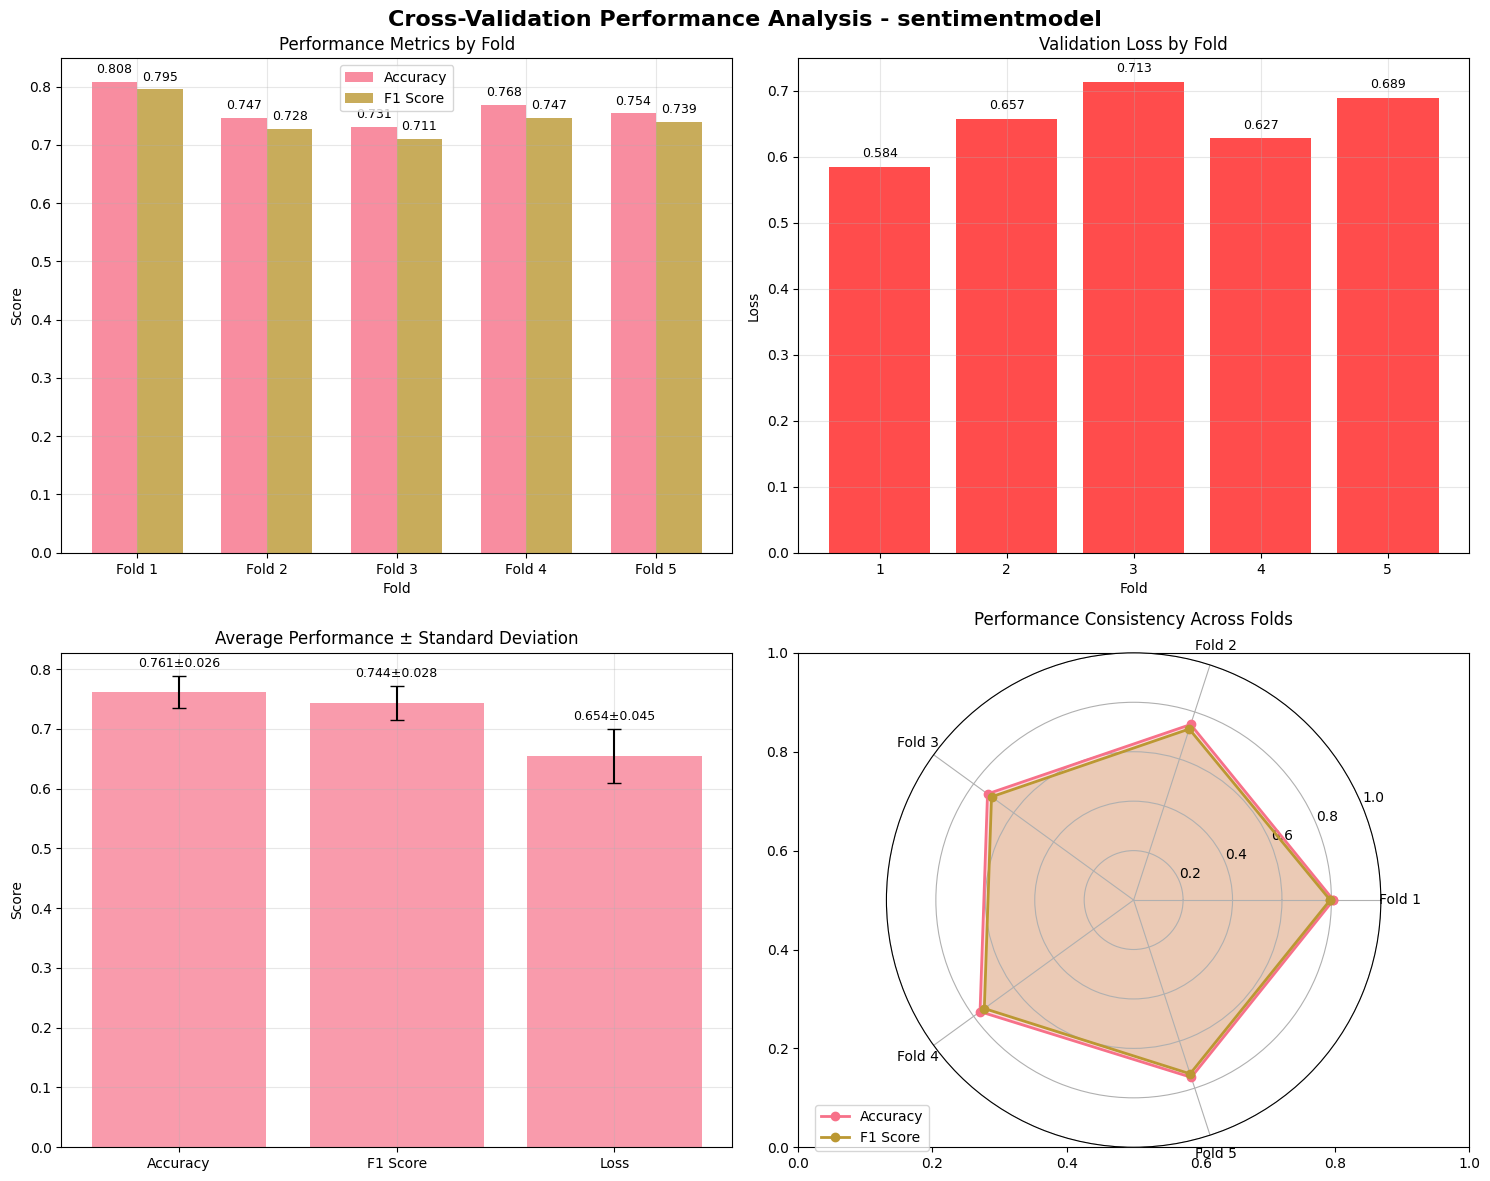


2. Model interpretability using real examples...
Creating model interpretability using real misclassified examples...
Loading best model from Fold 1
F1 Score: 0.7950
Found checkpoints: ['checkpoint-700']
Using latest checkpoint: ./results_sentimentmodel_fold_0\checkpoint-700
Model loaded successfully from: ./results_sentimentmodel_fold_0\checkpoint-700
Loaded best sentimentmodel model from Fold 1


C:\Users\Rafa Parkoureiro\AppData\Local\Temp\ipykernel_12512\3672099390.py:205: UserWarning: Glyph 129335 (\N{SHRUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Rafa Parkoureiro\AppData\Local\Temp\ipykernel_12512\3672099390.py:206: UserWarning: Glyph 129335 (\N{SHRUG}) missing from font(s) DejaVu Sans.
  plt.savefig(f'real_interpretability_{experiment_name}.png', dpi=300, bbox_inches='tight')
c:\Users\Rafa Parkoureiro\anaconda3\envs\NLP\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129335 (\N{SHRUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


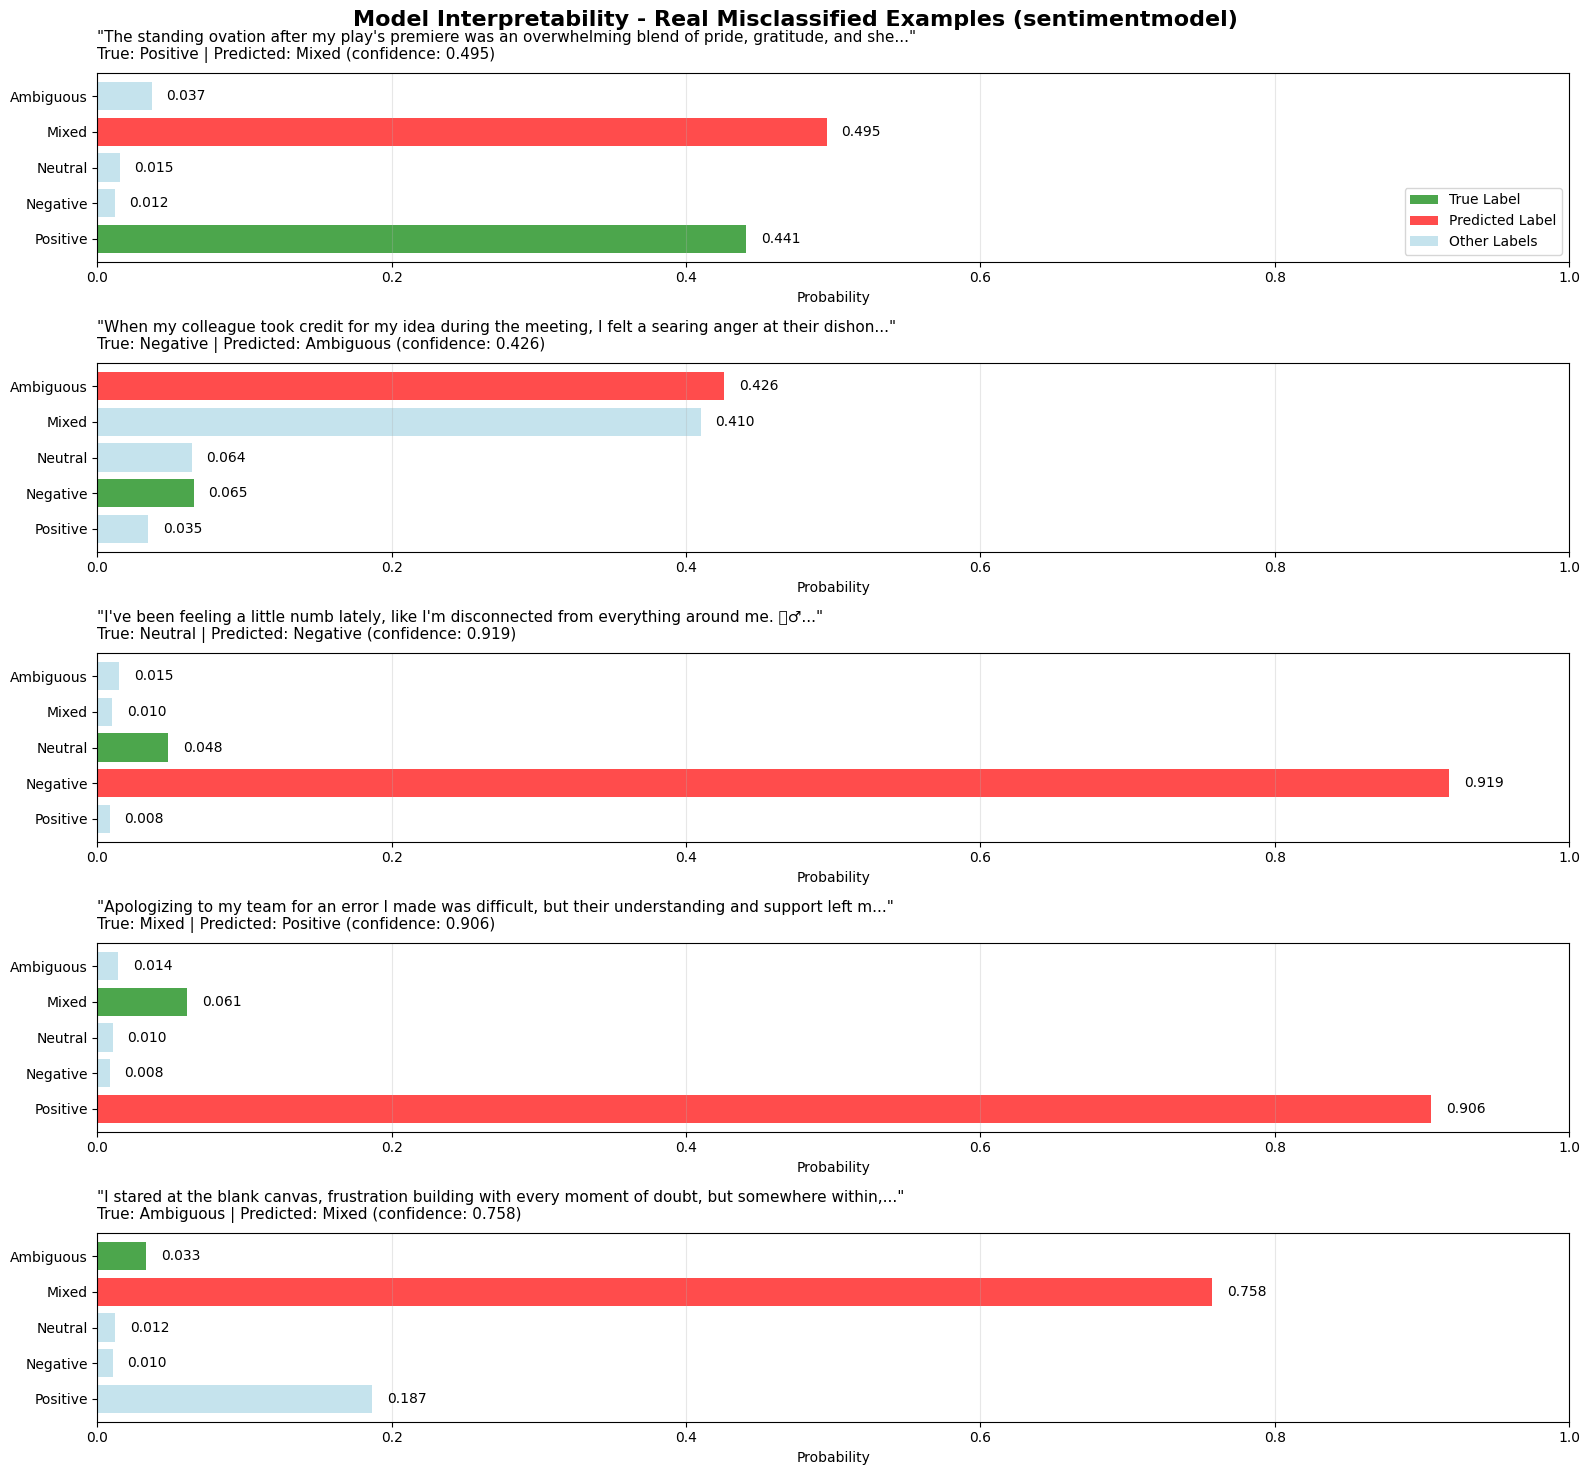


3. Real model attention analysis...
Creating REAL word influence analysis using LIME...
Loading best model from Fold 1
F1 Score: 0.7950
Found checkpoints: ['checkpoint-700']
Using latest checkpoint: ./results_sentimentmodel_fold_0\checkpoint-700
Model loaded successfully from: ./results_sentimentmodel_fold_0\checkpoint-700
Loaded best sentimentmodel model from Fold 1
Analyzing example 1 with LIME...

LIME Analysis for Example 1:
Predicted: Mixed
Top words influencing prediction:
  'disbelief': 0.450 (SUPPORTS prediction)
  'my': 0.116 (SUPPORTS prediction)
  'pride': -0.089 (OPPOSES prediction)
  'gratitude': -0.086 (OPPOSES prediction)
  'blend': 0.068 (SUPPORTS prediction)
Analyzing example 2 with LIME...

LIME Analysis for Example 2:
Predicted: Ambiguous
Top words influencing prediction:
  'anger': 0.087 (SUPPORTS prediction)
  'resolve': 0.084 (SUPPORTS prediction)
  'but': 0.040 (SUPPORTS prediction)
  'to': 0.038 (SUPPORTS prediction)
  'searing': 0.037 (SUPPORTS prediction)
Ana

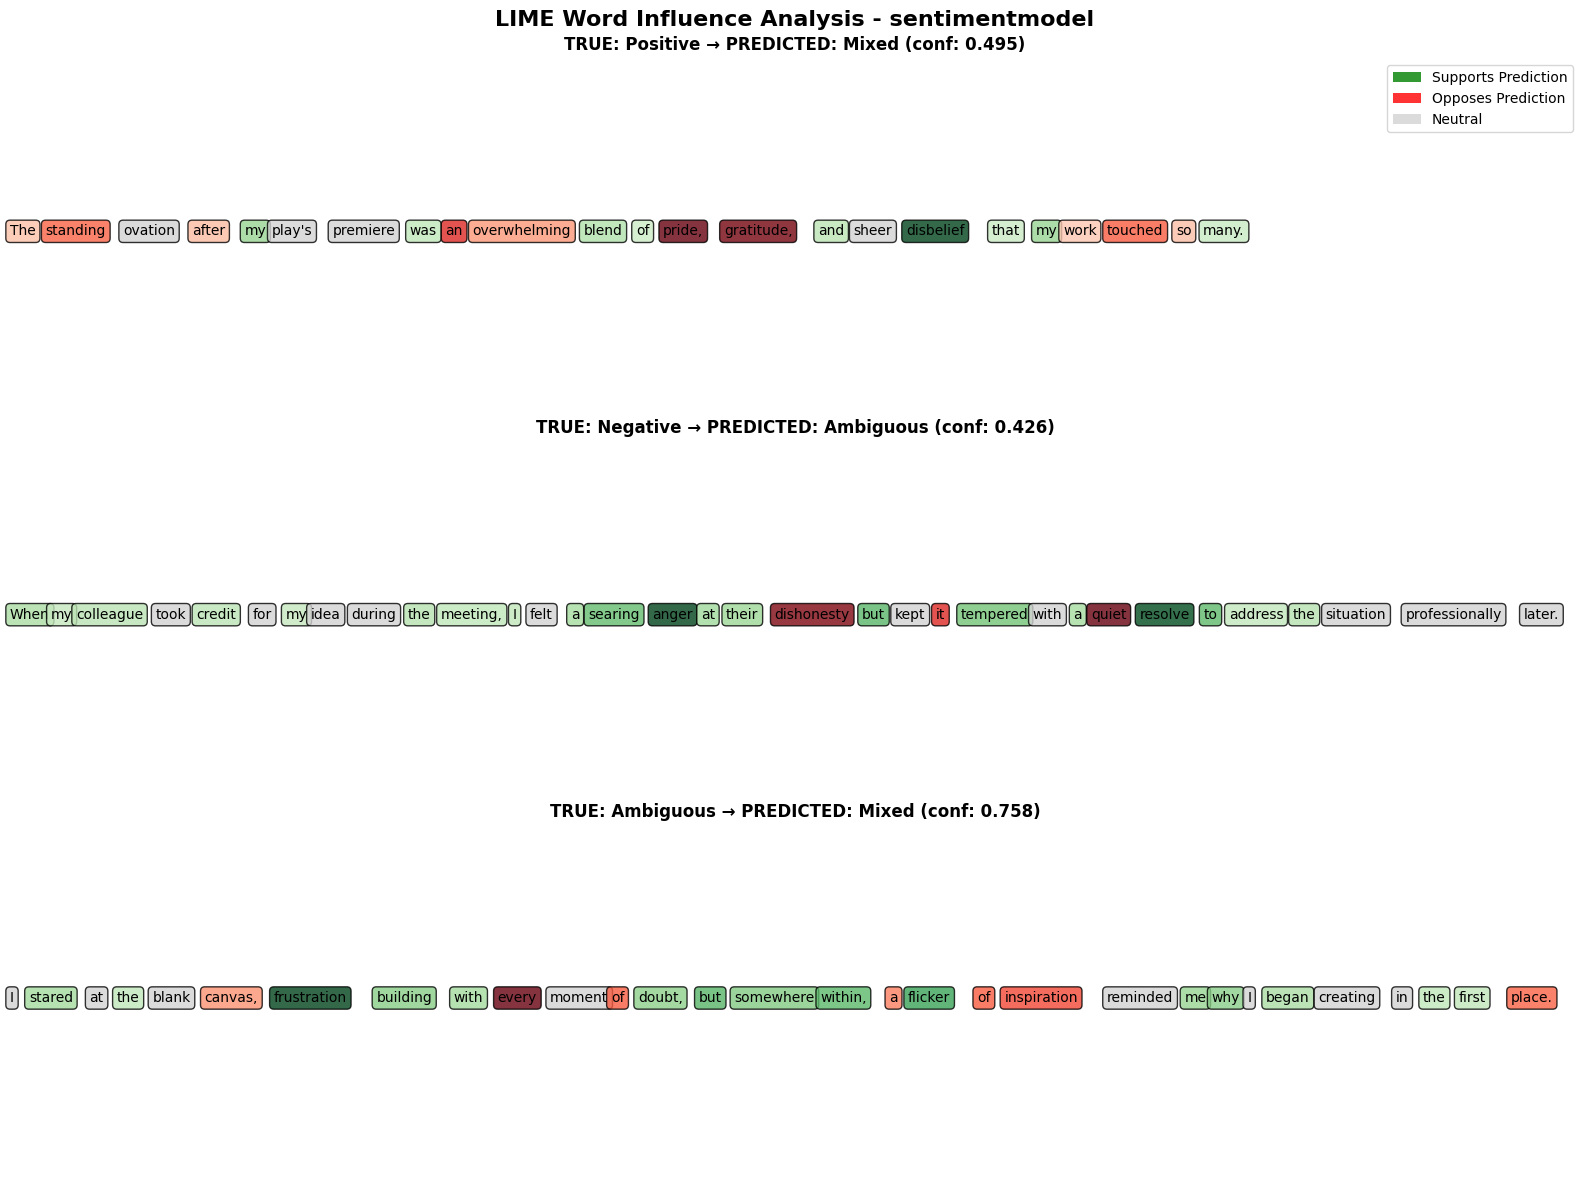


LIME Analysis Complete!
Green = words supporting the (wrong) prediction
Red = words opposing the (wrong) prediction
This shows what the model actually focuses on!

4. Prediction confidence analysis...
Creating prediction confidence analysis...
Loading best model from Fold 1
F1 Score: 0.7950
Found checkpoints: ['checkpoint-700']
Using latest checkpoint: ./results_sentimentmodel_fold_0\checkpoint-700
Model loaded successfully from: ./results_sentimentmodel_fold_0\checkpoint-700
Loaded best sentimentmodel model from Fold 1
Analyzing 375 test samples...


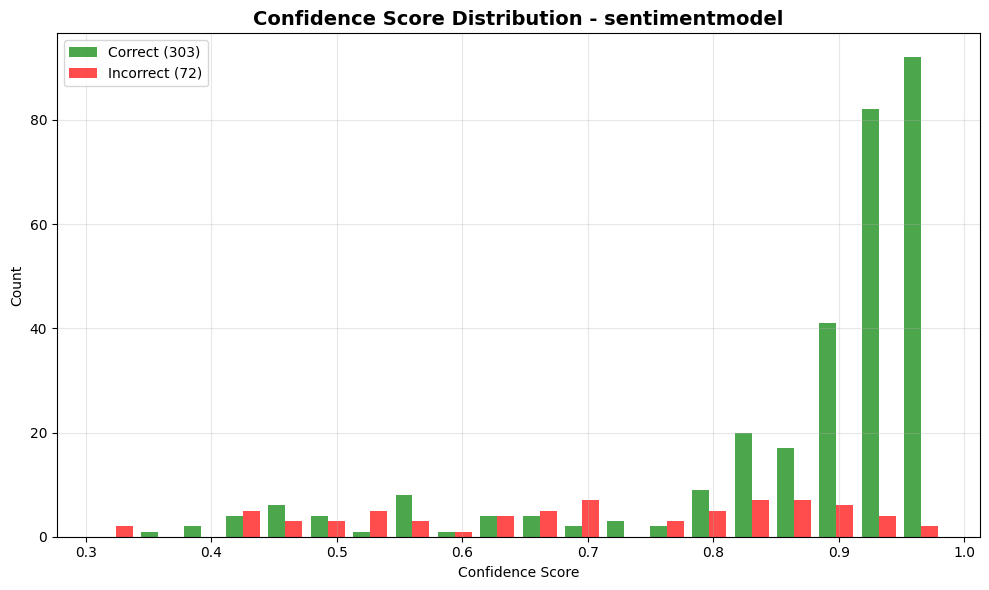


Confidence Analysis Summary:
Average confidence: 0.843
Confidence std: 0.164
Correct predictions avg confidence: 0.876
Incorrect predictions avg confidence: 0.702

All visualizations created!
Generated files for sentimentmodel:
- cv_performance_analysis_sentimentmodel.png
- real_interpretability_sentimentmodel.png
- real_model_analysis_sentimentmodel.png
- prediction_confidence_analysis_sentimentmodel.png


In [35]:
create_all_visualizations(experiment_name='sentimentmodel')

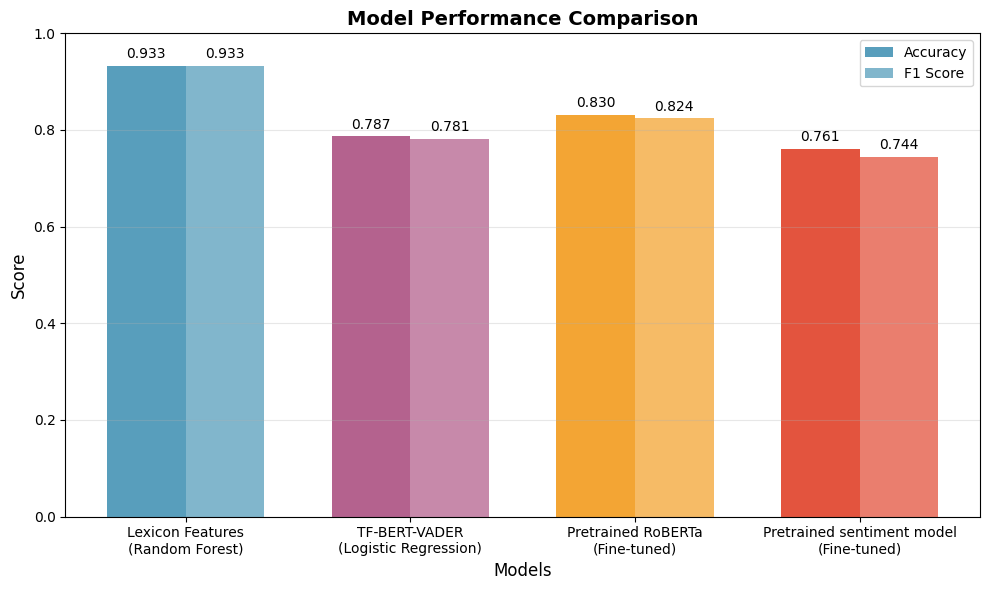

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Your model results
models = ['Lexicon Features\n(Random Forest)', 'TF-BERT-VADER\n(Logistic Regression)', 'Pretrained RoBERTa\n(Fine-tuned)', 'Pretrained sentiment model\n(Fine-tuned)']
accuracy = [0.9333, 0.7867, 0.8303,0.7615]
f1_score = [0.9334, 0.7810, 0.8239,0.7438]

# Set up the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Colors for each model
colors = ['#2E86AB', '#A23B72', '#F18F01', "#DD290D"]

# Side-by-side bar chart
x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', color=colors, alpha=0.8)
bars2 = ax.bar(x + width/2, f1_score, width, label='F1 Score', color=colors, alpha=0.6)

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()
